# import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, auc

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import matplotlib.pyplot as plt

# Read the Parquet File

In [2]:
df = pd.read_parquet('predictive_maintenance_log_v5_featured.parquet')

print(df.head())

                              PrinterID ReferenceDate  log_alert_count_3m  \
0  4da956db-a9bd-490c-8570-0a18c3fcb2f0    2025-07-01            5.463832   
1  0eb0bdd6-0308-4a0b-9c06-c8b1d6f5b171    2025-07-01            5.075174   
2  c4c7a34a-3130-4320-9eaf-7c11c0cc0f0d    2025-07-01            4.691348   
3  3b1c643d-0adc-4f34-972a-60d8cc7e5cbb    2025-07-01            4.430817   
4  5de0fc8d-3cee-4058-bf2f-47273d9766d6    2025-07-01            3.610918   

   log_warning_alert_count_3m  log_critical_alert_count_3m  \
0                    5.446737                     1.609438   
1                    5.017280                     2.302585   
2                    4.682131                     0.693147   
3                    0.000000                     3.637586   
4                    2.995732                     2.890372   

   unique_alert_codes_3m  log_alert_count_1m  log_warning_alert_count_1m  \
0                   11.0            4.744932                    4.736198   
1           

In [3]:
df

,PrinterID,ReferenceDate,log_alert_count_3m,log_warning_alert_count_3m,log_critical_alert_count_3m,unique_alert_codes_3m,log_alert_count_1m,log_warning_alert_count_1m,log_critical_alert_count_1m,unique_alert_codes_1m,...,critical_x_service_history,log_job_volume_3m,log_color_job_volume_3m,log_bw_job_volume_3m,log_job_volume_1m,job_growth_ratio,days_since_last_service,service_count_1yr,is_neglected,ServiceRequiredNext_30_Days
0,4da956db-a9bd-490c-8570-0a18c3fcb2f0,2025-07-01,5.463832,5.446737,1.609438,11.0,4.744932,4.736198,0.693147,6.0,...,0.0,7.594381,7.259820,6.318968,7.594381,1.0,530,0,1,0
1,0eb0bdd6-0308-4a0b-9c06-c8b1d6f5b171,2025-07-01,5.075174,5.017280,2.302585,12.0,4.025352,4.025352,0.000000,4.0,...,36.0,5.225747,4.605170,3.737670,5.225747,1.0,49,4,0,0
2,c4c7a34a-3130-4320-9eaf-7c11c0cc0f0d,2025-07-01,4.691348,4.682131,0.693147,5.0,4.204693,4.189655,0.693147,3.0,...,5.0,6.001415,0.000000,6.001415,6.001415,1.0,292,5,0,0
3,3b1c643d-0adc-4f34-972a-60d8cc7e5cbb,2025-07-01,4.430817,0.000000,3.637586,9.0,4.430817,0.000000,3.637586,9.0,...,185.0,4.624973,0.000000,4.624973,4.624973,1.0,25,5,0,1
4,5de0fc8d-3cee-4058-bf2f-47273d9766d6,2025-07-01,3.610918,2.995732,2.890372,11.0,2.995732,2.397895,2.302585,5.0,...,0.0,7.389564,5.950643,6.744059,7.389564,1.0,886,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460667,f73929d9-e7ef-4e8c-a27c-771b606d2c58,2025-05-01,6.006353,5.961005,2.944439,13.0,5.389072,5.337538,2.484907,6.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,1134,0,1,0
460668,466548f6-1527-4ec0-9a8f-e81f0822e593,2025-05-01,6.770789,5.673323,3.610918,23.0,6.049733,4.955827,2.564949,12.0,...,180.0,0.000000,0.000000,0.000000,0.000000,0.0,59,5,0,0
460669,38cf5715-572a-462e-9182-24ad551652c0,2025-05-01,5.869297,4.672829,0.000000,9.0,4.990433,3.761200,0.000000,4.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,577,0,1,0
460670,870931c5-1d3d-489d-8969-75bfe05d2274,2025-05-01,6.126869,5.963579,4.248495,19.0,4.644391,4.499810,2.708050,8.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,395,0,1,0


# Check Dataset Information

In [4]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460672 entries, 0 to 460671
Data columns (total 37 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   PrinterID                     460672 non-null  object        
 1   ReferenceDate                 460672 non-null  datetime64[us]
 2   log_alert_count_3m            460672 non-null  float64       
 3   log_warning_alert_count_3m    460672 non-null  float64       
 4   log_critical_alert_count_3m   460672 non-null  float64       
 5   unique_alert_codes_3m         460672 non-null  float64       
 6   log_alert_count_1m            460672 non-null  float64       
 7   log_warning_alert_count_1m    460672 non-null  float64       
 8   log_critical_alert_count_1m   460672 non-null  float64       
 9   unique_alert_codes_1m         460672 non-null  float64       
 10  critical_ratio_3m             460672 non-null  float64       
 11  critical_rati

# Remove Unnecessary Columns

In [5]:
df = df.drop(['PrinterID', 'ReferenceDate'], axis=1)

# Separate Features and Target

In [6]:
X = df.drop('ServiceRequiredNext_30_Days', axis=1)

y = df['ServiceRequiredNext_30_Days']

In [7]:
print(df['ServiceRequiredNext_30_Days'].value_counts())






ServiceRequiredNext_30_Days
0    395384
1     65288
Name: count, dtype: int64


# Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply Smote(Balanced Dataset)

In [9]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("Balanced dataset:")
print(pd.Series(y_train).value_counts())

Balanced dataset:
ServiceRequiredNext_30_Days
0    316307
1    316307
Name: count, dtype: int64


# Feature Scaling

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build Neural Network Model

In [11]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



# Compile Model

In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
15816/15816 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - accuracy: 0.7193 - loss: 0.5466 - val_accuracy: 0.4981 - val_loss: 0.7131
Epoch 2/10
15816/15816 ━━━━━━━━━━━━━━━━━━━━ 15s 974us/step - accuracy: 0.7269 - loss: 0.5350 - val_accuracy: 0.5355 - val_loss: 0.7219
Epoch 3/10
15816/15816 ━━━━━━━━━━━━━━━━━━━━ 15s 959us/step - accuracy: 0.7297 - loss: 0.5309 - val_accuracy: 0.5666 - val_loss: 0.6881
Epoch 4/10
15816/15816 ━━━━━━━━━━━━━━━━━━━━ 16s 985us/step - accuracy: 0.7313 - loss: 0.5282 - val_accuracy: 0.6184 - val_loss: 0.6779
Epoch 5/10
15816/15816 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - accuracy: 0.7328 - loss: 0.5268 - val_accuracy: 0.5716 - val_loss: 0.7174
Epoch 6/10
15816/15816 ━━━━━━━━━━━━━━━━━━━━ 15s 973us/step - accuracy: 0.7342 - loss: 0.5253 - val_accuracy: 0.5989 - val_loss: 0.6672
Epoch 7/10
15816/15816 ━━━━━━━━━━━━━━━━━━━━ 15s 957us/step - accuracy: 0.7349 - loss: 0.5243 - val_accuracy: 0.5896 - val_loss: 0.7149
Epoch 8/10
15816/15816 ━━━━━━━━━━━━━━━━━━━━ 15s 958us/step 

# Make Predictions

In [13]:
pred_prob = model.predict(X_test)

2880/2880 ━━━━━━━━━━━━━━━━━━━━ 1s 465us/step


# Precision-Recall Curve

In [14]:
precision, recall, thresholds = precision_recall_curve(y_test, pred_prob)

# Compute PR-AUC

In [15]:
pr_auc = auc(recall, precision)

print("PR-AUC Score:", pr_auc)

PR-AUC Score: 0.4266597485653797


# Plot Precision-Recall Curve

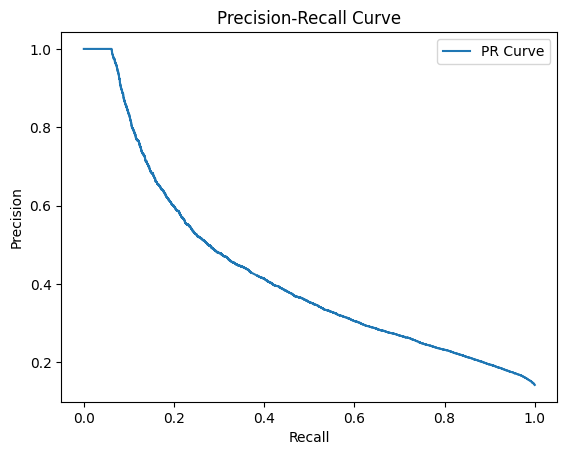

In [16]:
plt.plot(recall, precision, label="PR Curve")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

# Compute Confusion Matrix

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Convert probabilities to binary predictions (0 or 1)
predictions = (pred_prob > 0.5).astype(int)

# 2. Calculate metrics
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

# 3. Print the results
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")





Accuracy:  0.8043
Precision: 0.3599
Recall:    0.4893
F1-Score:  0.4148


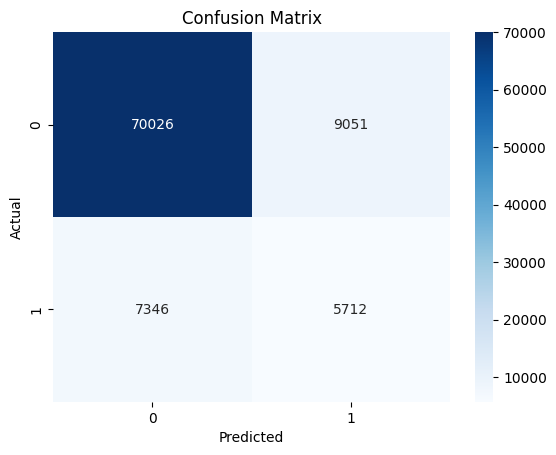

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions.flatten()
})

print(results.head(20))

    Actual  Predicted
0        0          0
1        0          0
2        0          1
3        0          0
4        0          0
5        0          0
6        0          0
7        0          0
8        1          1
9        0          0
10       0          0
11       0          0
12       0          1
13       0          0
14       1          1
15       0          0
16       1          1
17       0          0
18       0          0
19       0          0


In [ ]:
results["Correct"] = results["Actual"] == results["Predicted"]

print(results.head(20))

    Actual  Predicted  Correct
0        0          0     True
1        0          0     True
2        0          1    False
3        0          0     True
4        0          0     True
5        0          0     True
6        0          0     True
7        0          0     True
8        1          1     True
9        0          0     True
10       0          0     True
11       0          0     True
12       0          1    False
13       0          0     True
14       1          1     True
15       0          0     True
16       1          1     True
17       0          0     True
18       0          0     True
19       0          0     True


In [ ]:
correct_predictions = results["Correct"].sum()

print("Correct Predictions:", correct_predictions)

Correct Predictions: 75738


In [ ]:
incorrect_predictions = len(results) - correct_predictions

print("Incorrect Predictions:", incorrect_predictions)

Incorrect Predictions: 16397


In [ ]:
wrong_predictions = results[results["Correct"] == False]

print(wrong_predictions.head(20))

     Actual  Predicted  Correct
2         0          1    False
12        0          1    False
26        0          1    False
28        1          0    False
37        1          0    False
40        1          0    False
49        1          0    False
51        0          1    False
59        1          0    False
68        0          1    False
72        1          0    False
78        0          1    False
82        0          1    False
88        0          1    False
92        0          1    False
99        0          1    False
112       0          1    False
116       0          1    False
118       1          0    False
123       0          1    False


In [ ]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions.flatten(),
    "Probability": pred_prob.flatten()
})

print(results.head(20))

    Actual  Predicted  Probability
0        0          0     0.393069
1        0          0     0.345861
2        0          1     0.584748
3        0          0     0.350459
4        0          0     0.121287
5        0          0     0.280211
6        0          0     0.413692
7        0          0     0.395127
8        1          1     0.617687
9        0          0     0.270465
10       0          0     0.152684
11       0          0     0.211709
12       0          1     0.621005
13       0          0     0.145176
14       1          1     0.611657
15       0          0     0.239671
16       1          1     1.000000
17       0          0     0.132271
18       0          0     0.198480
19       0          0     0.467387
